## Cervical Cancer Immune Remodeling scRNA-seq Analysis

## Step 8.1: Loading Libraries & 10X Data into Scanpy

import scanpy as sc
import anndata as ad

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path


sc.settings.verbosity = 3

sc.settings.set_figure_params(
    dpi=120,
    facecolor="white",
    frameon=False
)

print("Environment ready")

In [4]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Configure Scanpy plotting settings
sc.settings.verbosity = 3

sc.settings.set_figure_params(
    dpi=120,
    facecolor="white",
    frameon=False
)


print("Libraries loaded")

Libraries loaded


In [5]:
# Data directory

data_dir = Path("../data")


print("Available samples:")
print(
    [p.name for p in data_dir.iterdir() if p.is_dir()]
)

Available samples:
['ADC_6', 'HSIL_1', 'HSIL_2', 'N_1', 'N_2', 'N_HPV_NEG_1', 'N_HPV_NEG_2', 'SCC_4', 'SCC_5']


In [6]:
# select all samples

selected_samples = [
    "N_HPV_NEG_1",
    "N_HPV_NEG_2",
    "N_1",
    "N_2",
    "HSIL_1",
    "HSIL_2",
    "SCC_4",
    "SCC_5",
    "ADC_6"
]


sample_dirs = [
    data_dir / s
    for s in selected_samples
    if (data_dir / s).exists()
]


print(
    f"Loading {len(sample_dirs)} samples:"
)

print(
    [p.name for p in sample_dirs]
)

Loading 9 samples:
['N_HPV_NEG_1', 'N_HPV_NEG_2', 'N_1', 'N_2', 'HSIL_1', 'HSIL_2', 'SCC_4', 'SCC_5', 'ADC_6']


In [7]:
# Read 10X matrices + metadata

adatas = {}


for sample_path in sample_dirs:

    sample_id = sample_path.name

    print("Loading:", sample_id)


    # Read 10X matrix directly
    adata_sample = sc.read_10x_mtx(
        path=sample_path,
        var_names="gene_symbols",
        cache=False
    )


    # Assign sample metadata
    adata_sample.obs["sample"] = sample_id


    # Group annotation

    if "HPV_NEG" in sample_id:

        adata_sample.obs["group"] = "Normal_HPV_Neg"
        adata_sample.obs["tissue_type"] = "Normal"


    elif sample_id.startswith("SCC"):

        adata_sample.obs["group"] = "Cervical_SCC"
        adata_sample.obs["tissue_type"] = "Tumor"


    elif sample_id.startswith("HSIL"):

        adata_sample.obs["group"] = "Precancerous_HSIL"
        adata_sample.obs["tissue_type"] = "Precancer"


    elif sample_id.startswith("ADC"):

        adata_sample.obs["group"] = "Cervical_ADC"
        adata_sample.obs["tissue_type"] = "Tumor"


    else:

        adata_sample.obs["group"] = "Normal_HPV_Pos"
        adata_sample.obs["tissue_type"] = "Normal"


    adatas[sample_id] = adata_sample



print("All samples loaded")

Loading: N_HPV_NEG_1
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading: N_HPV_NEG_2
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading: N_1
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading: N_2
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading: HSIL_1
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading: HSIL_2
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading: SCC_4
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading: SCC_5
--> This might be very slow. Consider passing `cache=True`, which enables much 

In [8]:
# Merge all samples

adata = ad.concat(
    adatas,
    label="sample_batch",
    index_unique="-",
    join="outer"
)


adata.var_names_make_unique()


print(
    f"Merged Dataset: {adata.n_obs} cells x {adata.n_vars} genes"
)

Merged Dataset: 83959 cells x 20615 genes


In [9]:
# Save raw merged AnnData

results_dir = Path("../results")

results_dir.mkdir(
    exist_ok=True
)


adata.write(
    results_dir / "human_cervix_all_samples_raw.h5ad"
)


print("Raw merged AnnData saved")

Raw merged AnnData saved


# Step 8.2: Quality Control (QC) & Filtering

In [10]:
# 1. Annotate QC gene groups

# Mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")


# Ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(
    ("RPS", "RPL")
)


# Hemoglobin genes
adata.var["hb"] = adata.var_names.str.startswith(
    (
        "HBA",
        "HBB",
        "HBD",
        "HBE",
        "HBG",
        "HBM",
        "HBQ",
        "HBZ"
    )
)


print("QC gene annotation completed")

QC gene annotation completed


In [11]:
# 2. Compute QC metrics

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True
)

print("QC metrics calculated")

QC metrics calculated


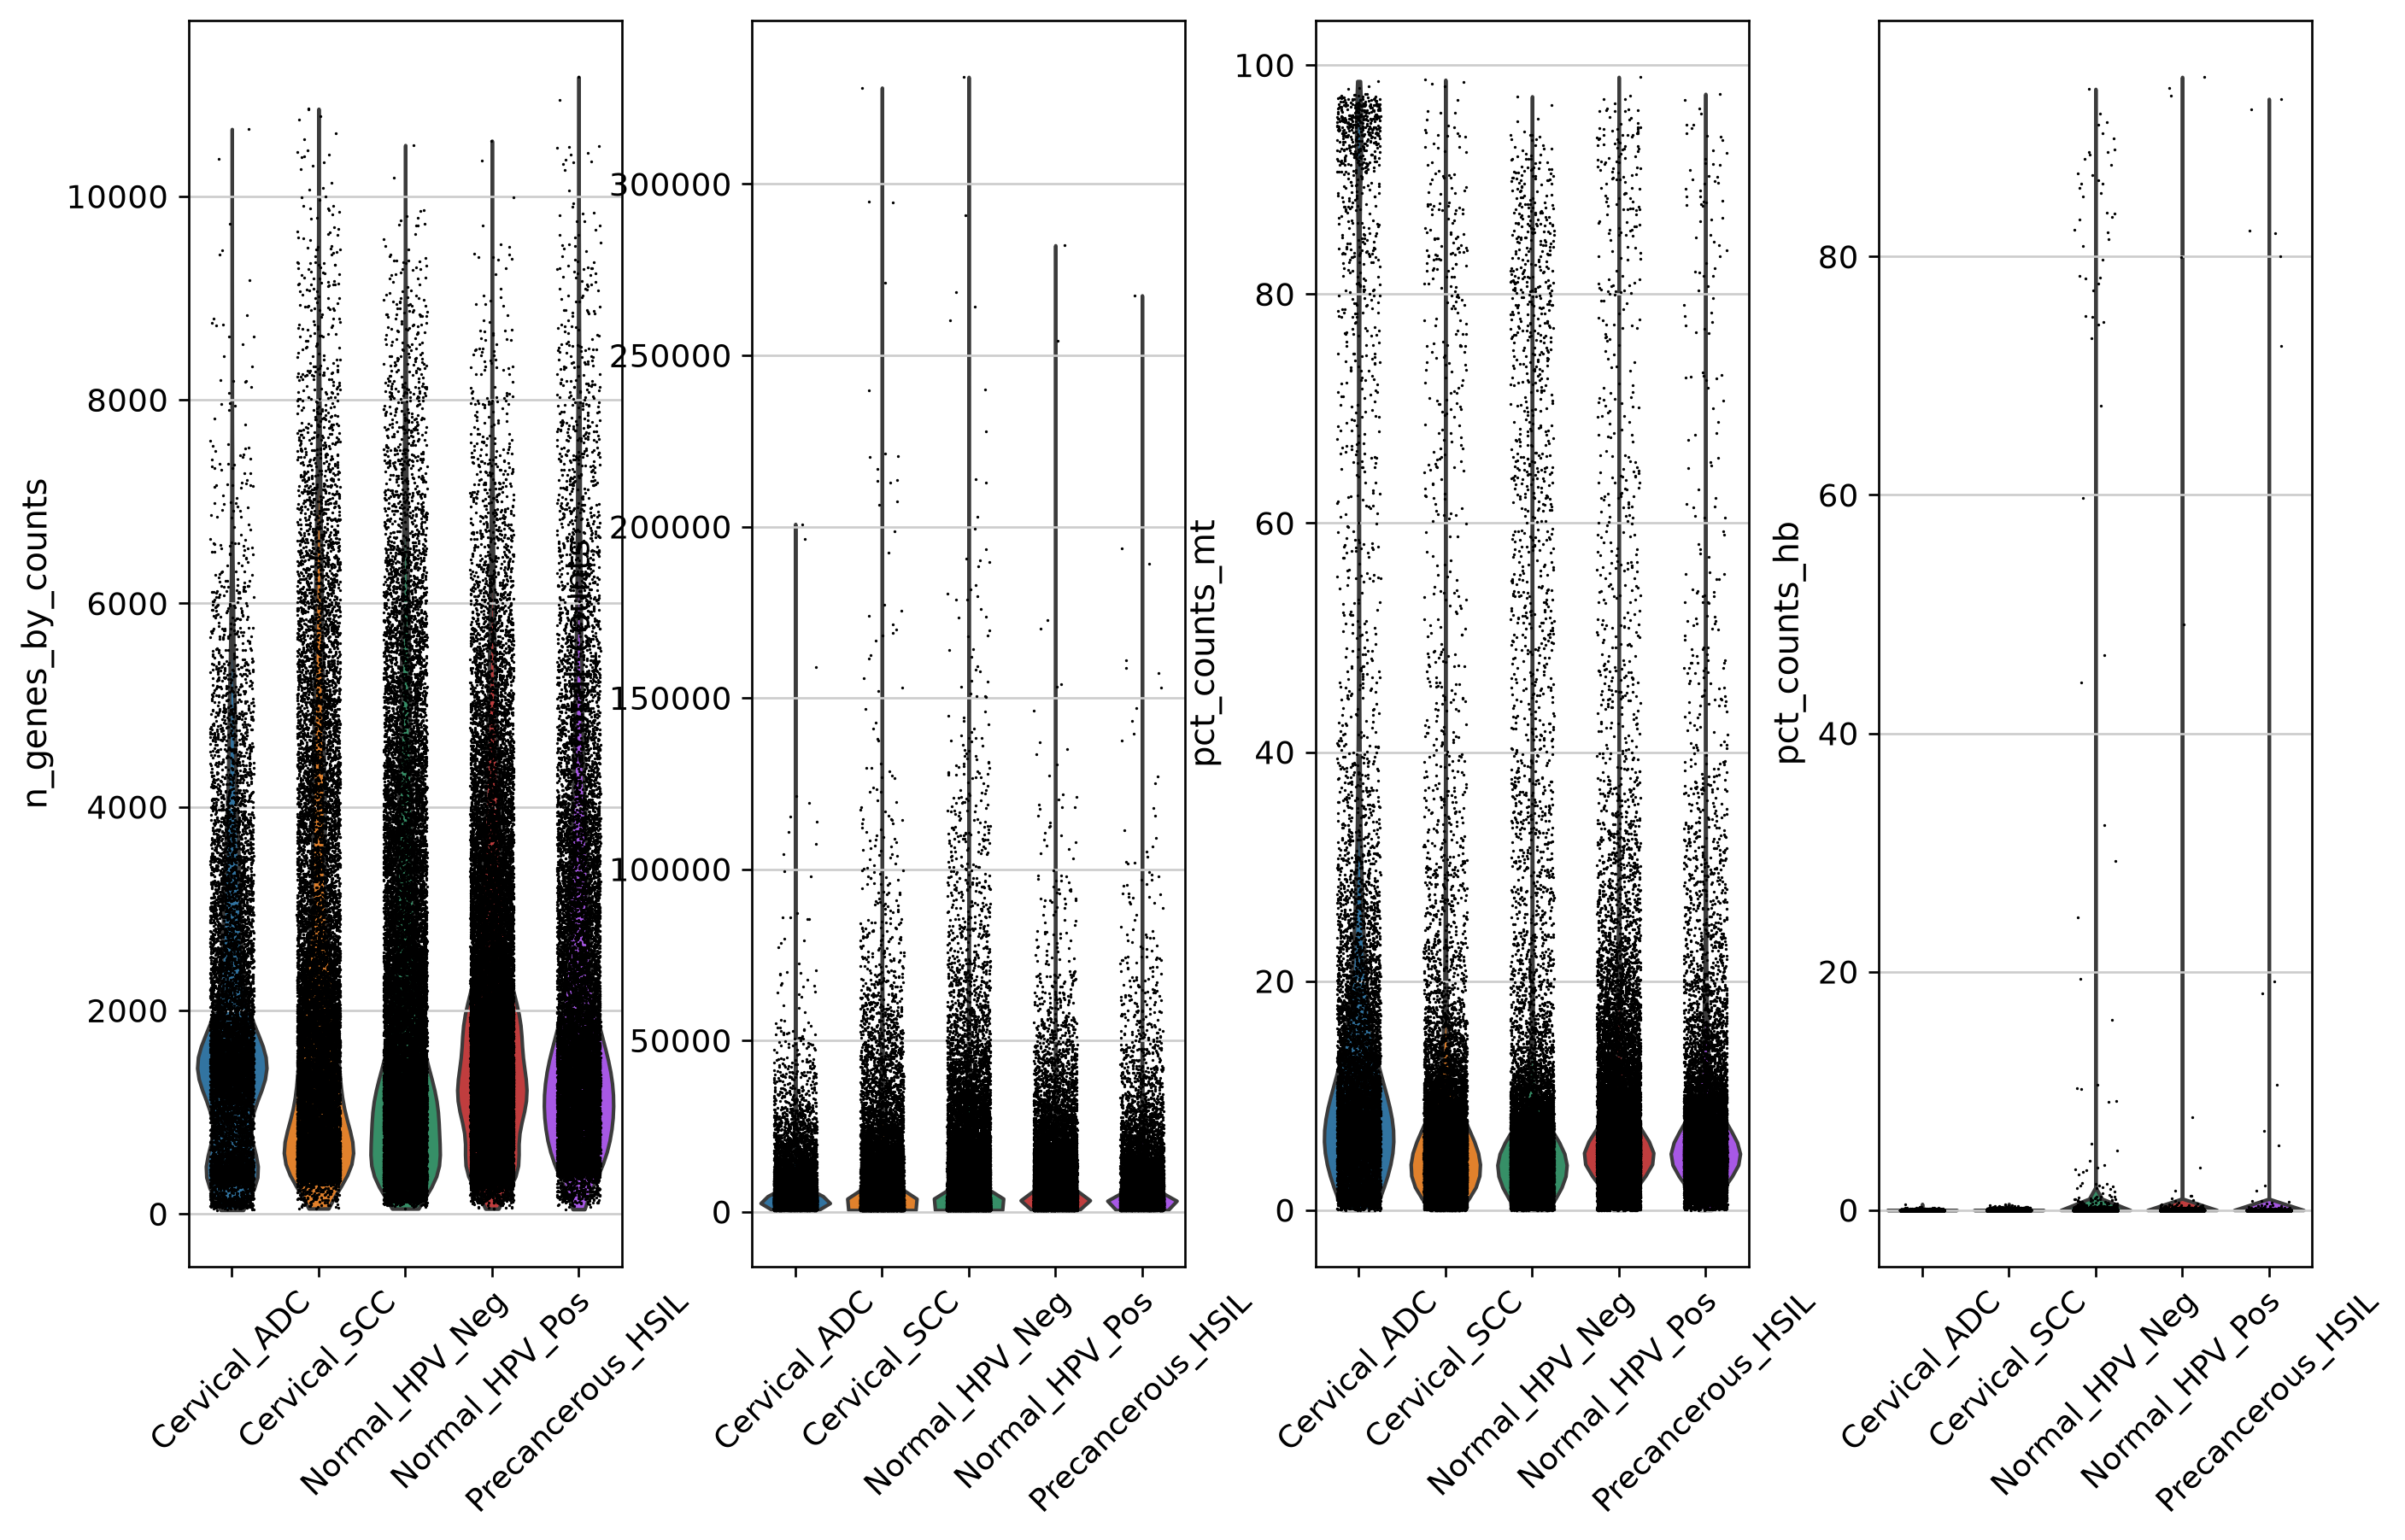

Publication-quality QC violin plot saved


In [12]:
# 3. QC Visualization 

import matplotlib.pyplot as plt

# Set publication style
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


# Generate QC violin plots

sc.pl.violin(
    adata,
    keys=[
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "pct_counts_hb"
    ],
    groupby="group",
    jitter=0.25,
    multi_panel=True,
    rotation=45,
    show=False
)


# Figure size
fig = plt.gcf()
fig.set_size_inches(14, 8)


# Save publication quality figures

fig.savefig(
    "../results/Figure_QC_violin.png",
    dpi=600,
    bbox_inches="tight"
)


fig.savefig(
    "../results/Figure_QC_violin.pdf",
    bbox_inches="tight"
)


plt.show()


print("Publication-quality QC violin plot saved")

In [13]:
# 4. Filter cells and genes

sc.pp.filter_cells(
    adata,
    min_genes=250
)

sc.pp.filter_genes(
    adata,
    min_cells=5
)

adata = adata[
    adata.obs["pct_counts_mt"] < 15.0,
    :
].copy()

adata = adata[
    adata.obs["pct_counts_hb"] < 5.0,
    :
].copy()


print(f"Cells remaining after QC: {adata.n_obs}")
print(f"Genes remaining after QC: {adata.n_vars}")

filtered out 1747 cells that have less than 250 genes expressed
filtered out 2254 genes that are detected in less than 5 cells
Cells remaining after QC: 74722
Genes remaining after QC: 18361


In [14]:
adata.write(
    "../results/human_cervix_QC_filtered.h5ad"
)

print("QC filtered data saved")

QC filtered data saved


# Step 8.3: Normalization & Feature Selection

In [15]:
# Store raw counts

adata.layers["counts"] = adata.X.copy()

print("Raw counts stored")

Raw counts stored


In [16]:
# Total count normalization to 10,000

sc.pp.normalize_total(
    adata,
    target_sum=1e4
)

print("Normalization completed")

normalizing counts per cell
    finished (0:00:00)
Normalization completed


In [17]:
# Log1p transformation

sc.pp.log1p(adata)

print("Log transformation completed")

Log transformation completed


In [18]:
adata.raw = adata

print("Raw expression saved")

Raw expression saved


In [19]:
# Identify 2,500 highly variable genes

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2500,
    batch_key="sample"
)

print(
    "HVG selected:",
    adata.var.highly_variable.sum()
)

extracting highly variable genes
    finished (0:00:12)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
HVG selected: 2500


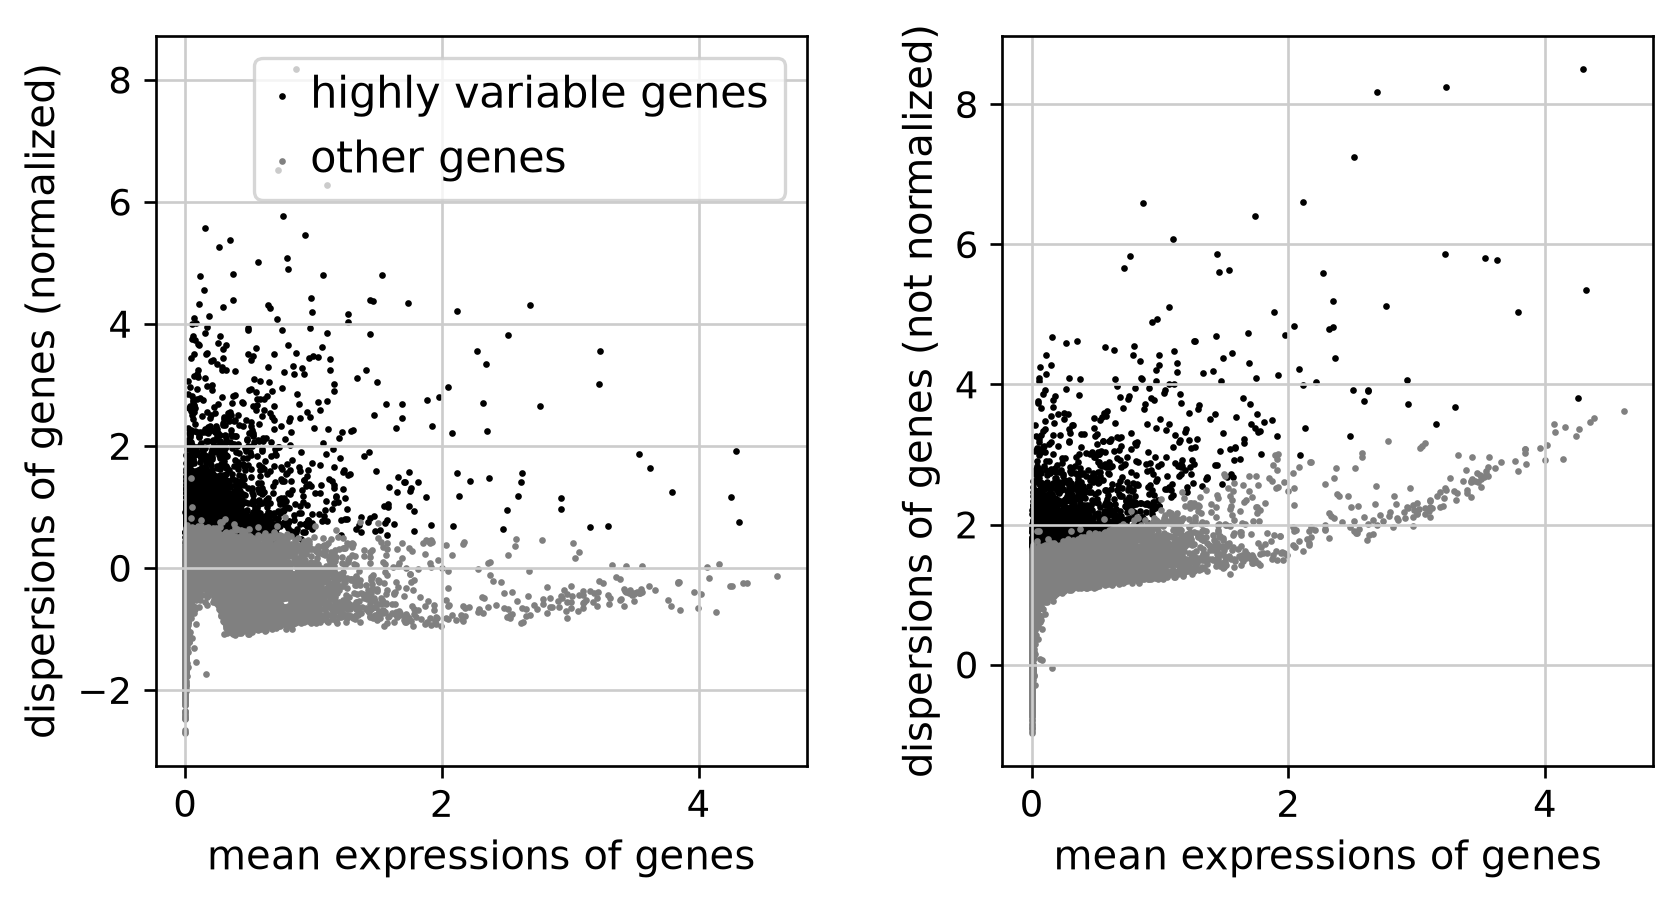

In [20]:
sc.pl.highly_variable_genes(adata)

In [21]:
# Save normalized HVG processed AnnData

adata.write(
    "../results/human_cervix_normalized_HVG.h5ad"
)

print("Normalized HVG data saved")

Normalized HVG data saved


# Step 8.4: Dimensionality Reduction & Graph-Based Clustering

In [26]:
import scanpy as sc

adata = sc.read_h5ad(
    "../results/human_cervix_normalized_HVG.h5ad"
)

print(adata)

AnnData object with n_obs × n_vars = 74722 × 18361
    obs: 'sample', 'group', 'tissue_type', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'group_colors', 'hvg', 'log1p'
    layers: 'counts'


In [27]:
# PCA

sc.tl.pca(
    adata,
    svd_solver="arpack",
    use_highly_variable=True
)

print("PCA completed")

computing PCA


/mnt/e/project4_immune_remodeling_cc/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    with n_comps=50
    finished (0:00:04)
PCA completed


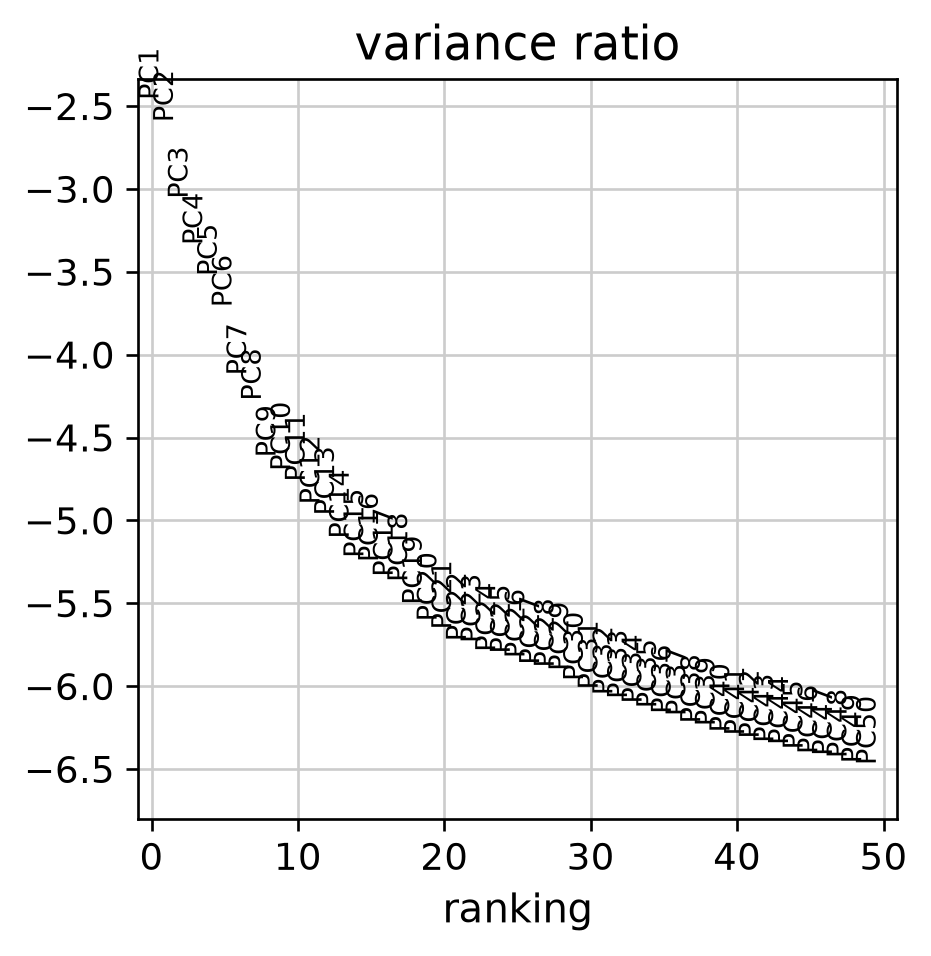

In [28]:
# PCA variance ratio plot

sc.pl.pca_variance_ratio(
    adata,
    log=True,
    n_pcs=50
)

In [29]:
# Build neighbor graph

sc.pp.neighbors(
    adata,
    n_neighbors=20,
    n_pcs=30
)

print("Neighbor graph completed")

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
Neighbor graph completed


In [30]:
# Compute UMAP

sc.tl.umap(
    adata
)

print("UMAP completed")

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:39)
UMAP completed


In [31]:
# Leiden clustering

sc.tl.leiden(
    adata,
    resolution=0.8,
    key_added="leiden_res_0.8"
)

print("Leiden clustering completed")

running Leiden clustering


/tmp/ipykernel_1510/2473849924.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


    finished: found 41 clusters and added
    'leiden_res_0.8', the cluster labels (adata.obs, categorical) (0:01:49)
Leiden clustering completed


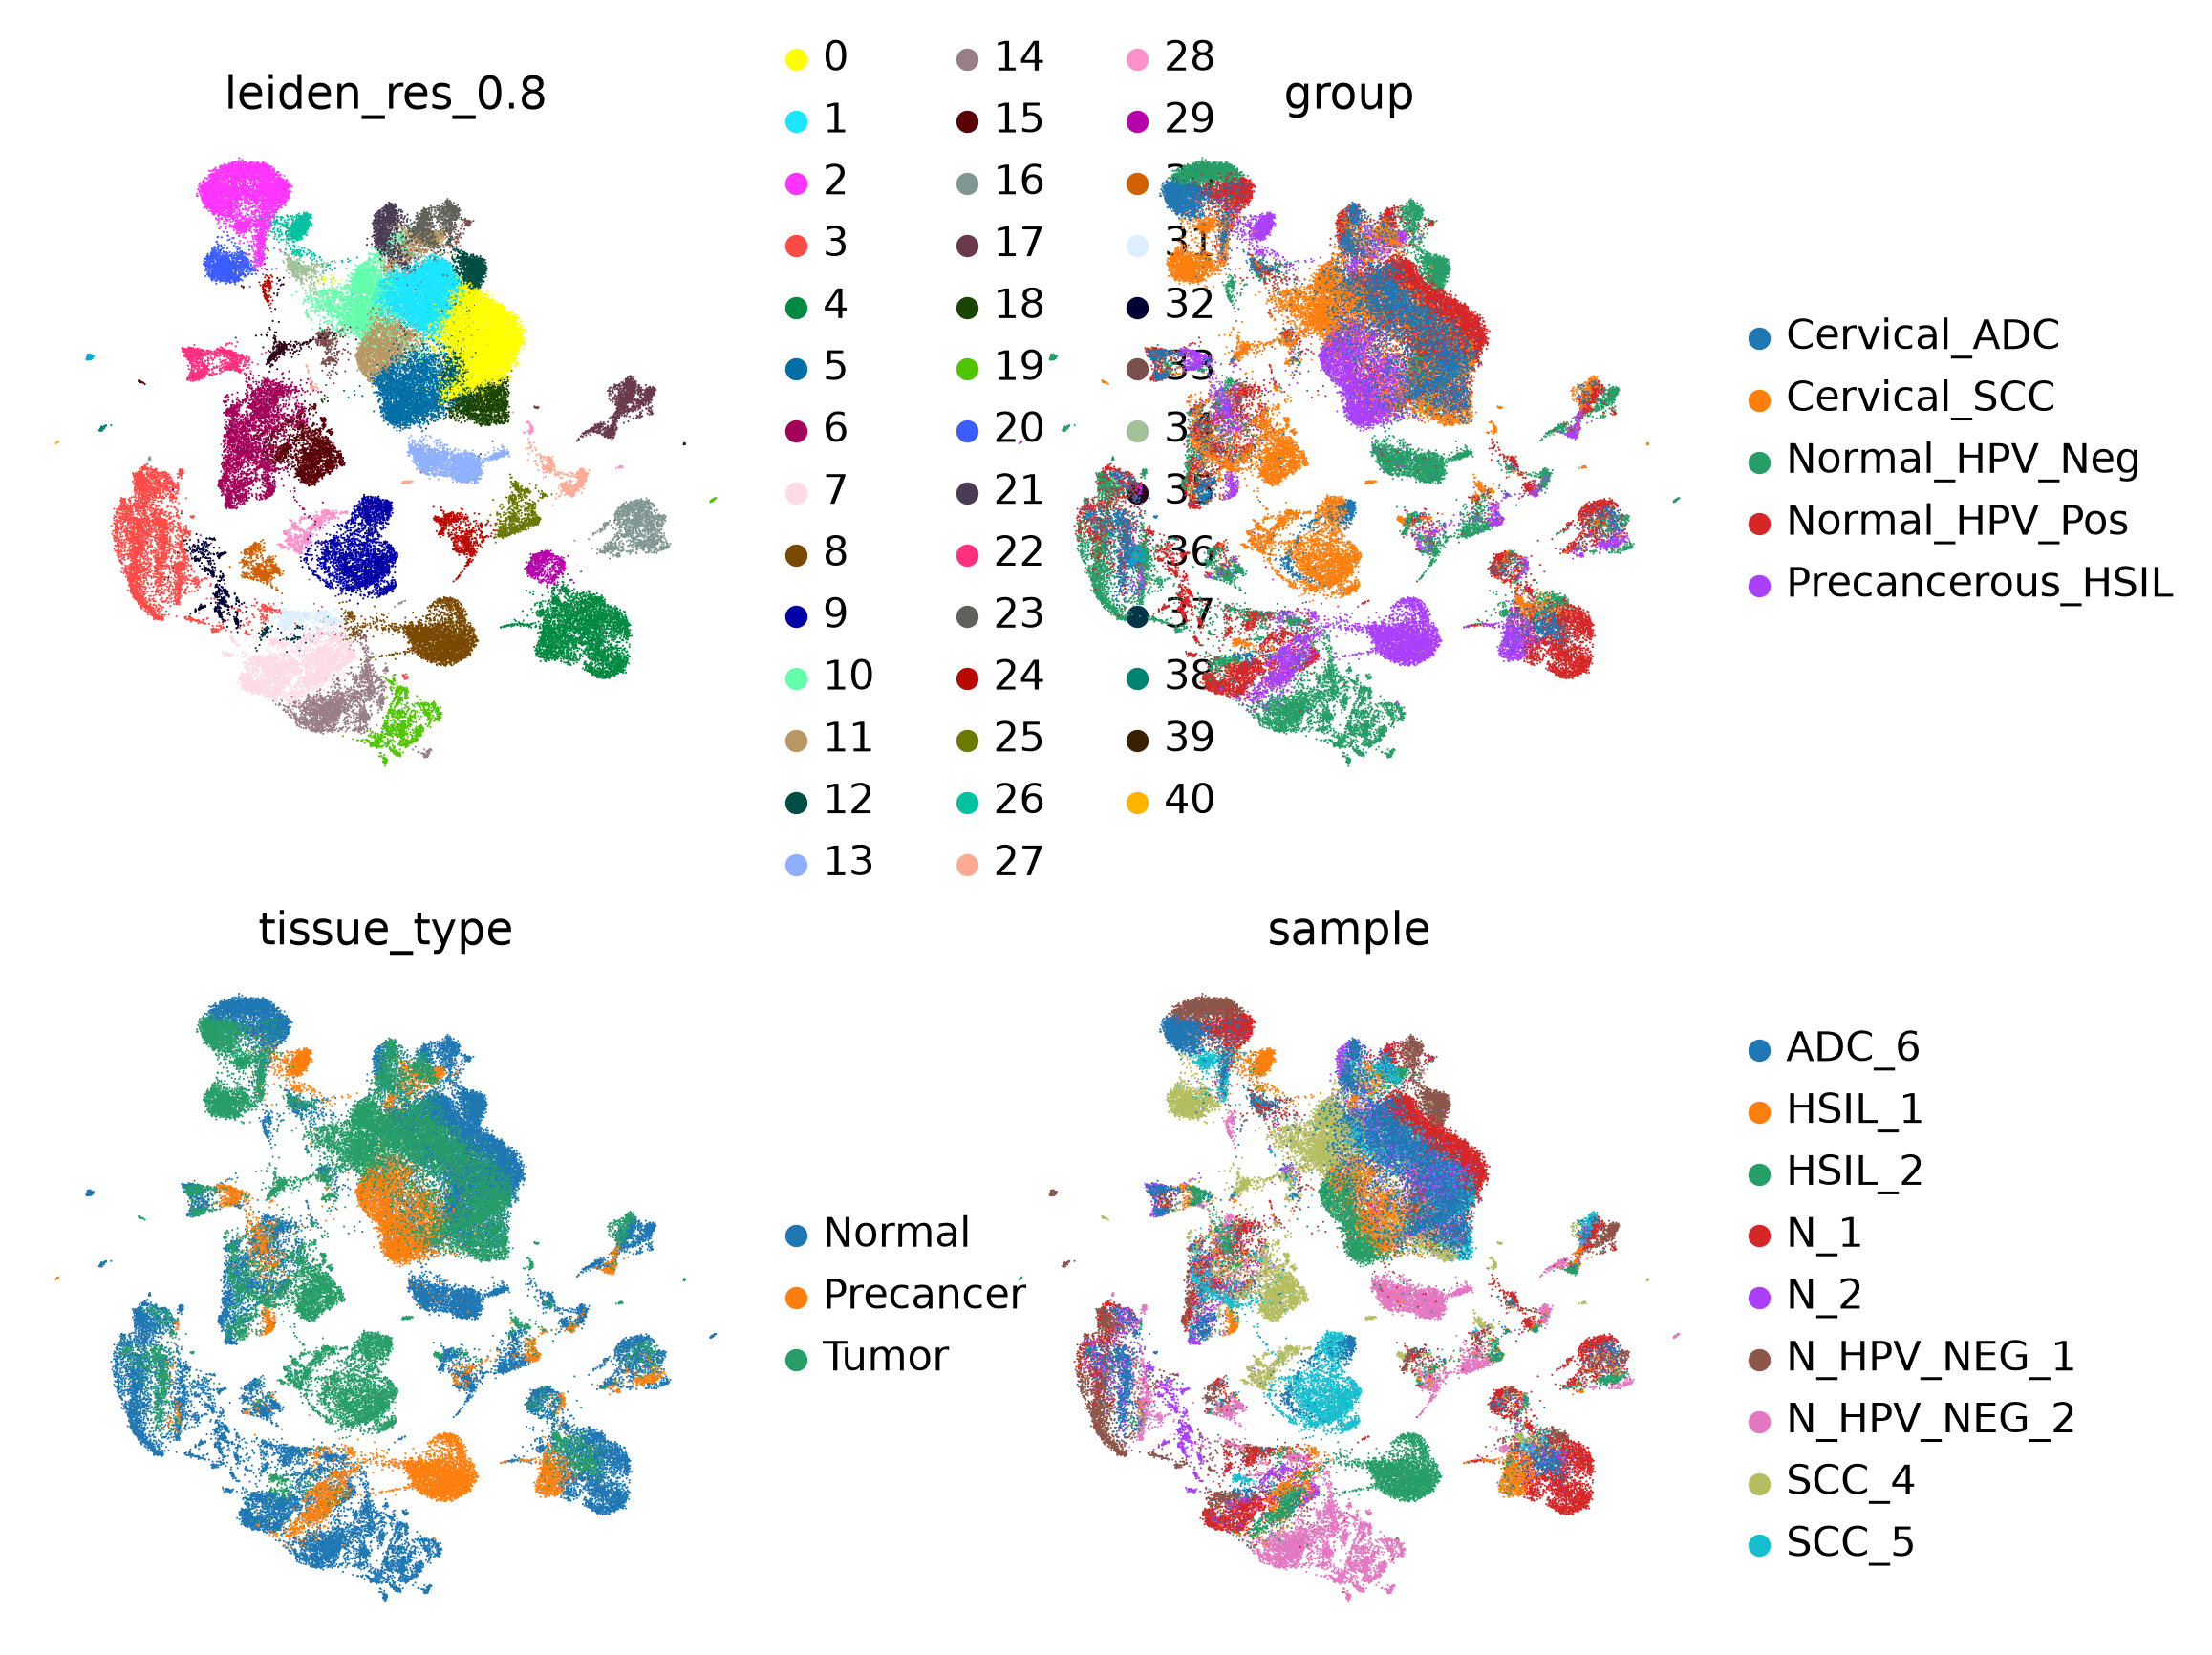

In [32]:
# UMAP plots

sc.pl.umap(
    adata,
    color=[
        "leiden_res_0.8",
        "group",
        "tissue_type",
        "sample"
    ],
    ncols=2
)

In [33]:
import matplotlib.pyplot as plt

sc.pl.umap(
    adata,
    color=[
        "leiden_res_0.8",
        "group",
        "tissue_type",
        "sample"
    ],
    ncols=2,
    show=False
)

plt.savefig(
    "../results/UMAP_leiden_group_tissue_sample.png",
    dpi=600,
    bbox_inches="tight"
)

plt.close()

print("UMAP figure saved")

UMAP figure saved


In [1]:
import sys

print(sys.executable)

/mnt/e/project4_immune_remodeling_cc/.venv/bin/python


In [2]:
import igraph
import leidenalg

print("igraph and leidenalg OK")

igraph and leidenalg OK


In [3]:
import scanpy as sc

adata = sc.read_h5ad(
    "../results/human_cervix_normalized_HVG_scaled.h5ad"
)

print(adata)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../results/human_cervix_normalized_HVG_scaled.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

# Step 8.5: Tumor Microenvironment Cell Type Annotation


In [34]:
# Tumor microenvironment lineage markers

lineage_dict = {

    "Epithelial_Tumor": [
        "EPCAM",
        "KRT5",
        "KRT14"
    ],

    "T_cells": [
        "CD3D",
        "CD4",
        "CD8A"
    ],

    "Tregs": [
        "FOXP3",
        "IL2RA",
        "CTLA4"
    ],

    "NK": [
        "NKG7",
        "NCAM1"
    ],

    "B_cells": [
        "MS4A1",
        "CD79A"
    ],

    "Plasma": [
        "SDC1",
        "MZB1"
    ],

    "Myeloid_TAM": [
        "CD14",
        "CD68",
        "CD163"
    ],

    "Fibroblasts": [
        "COL1A1",
        "ACTA2"
    ],

    "Endothelial": [
        "PECAM1",
        "VWF"
    ]

}

print("Lineage markers loaded")

Lineage markers loaded


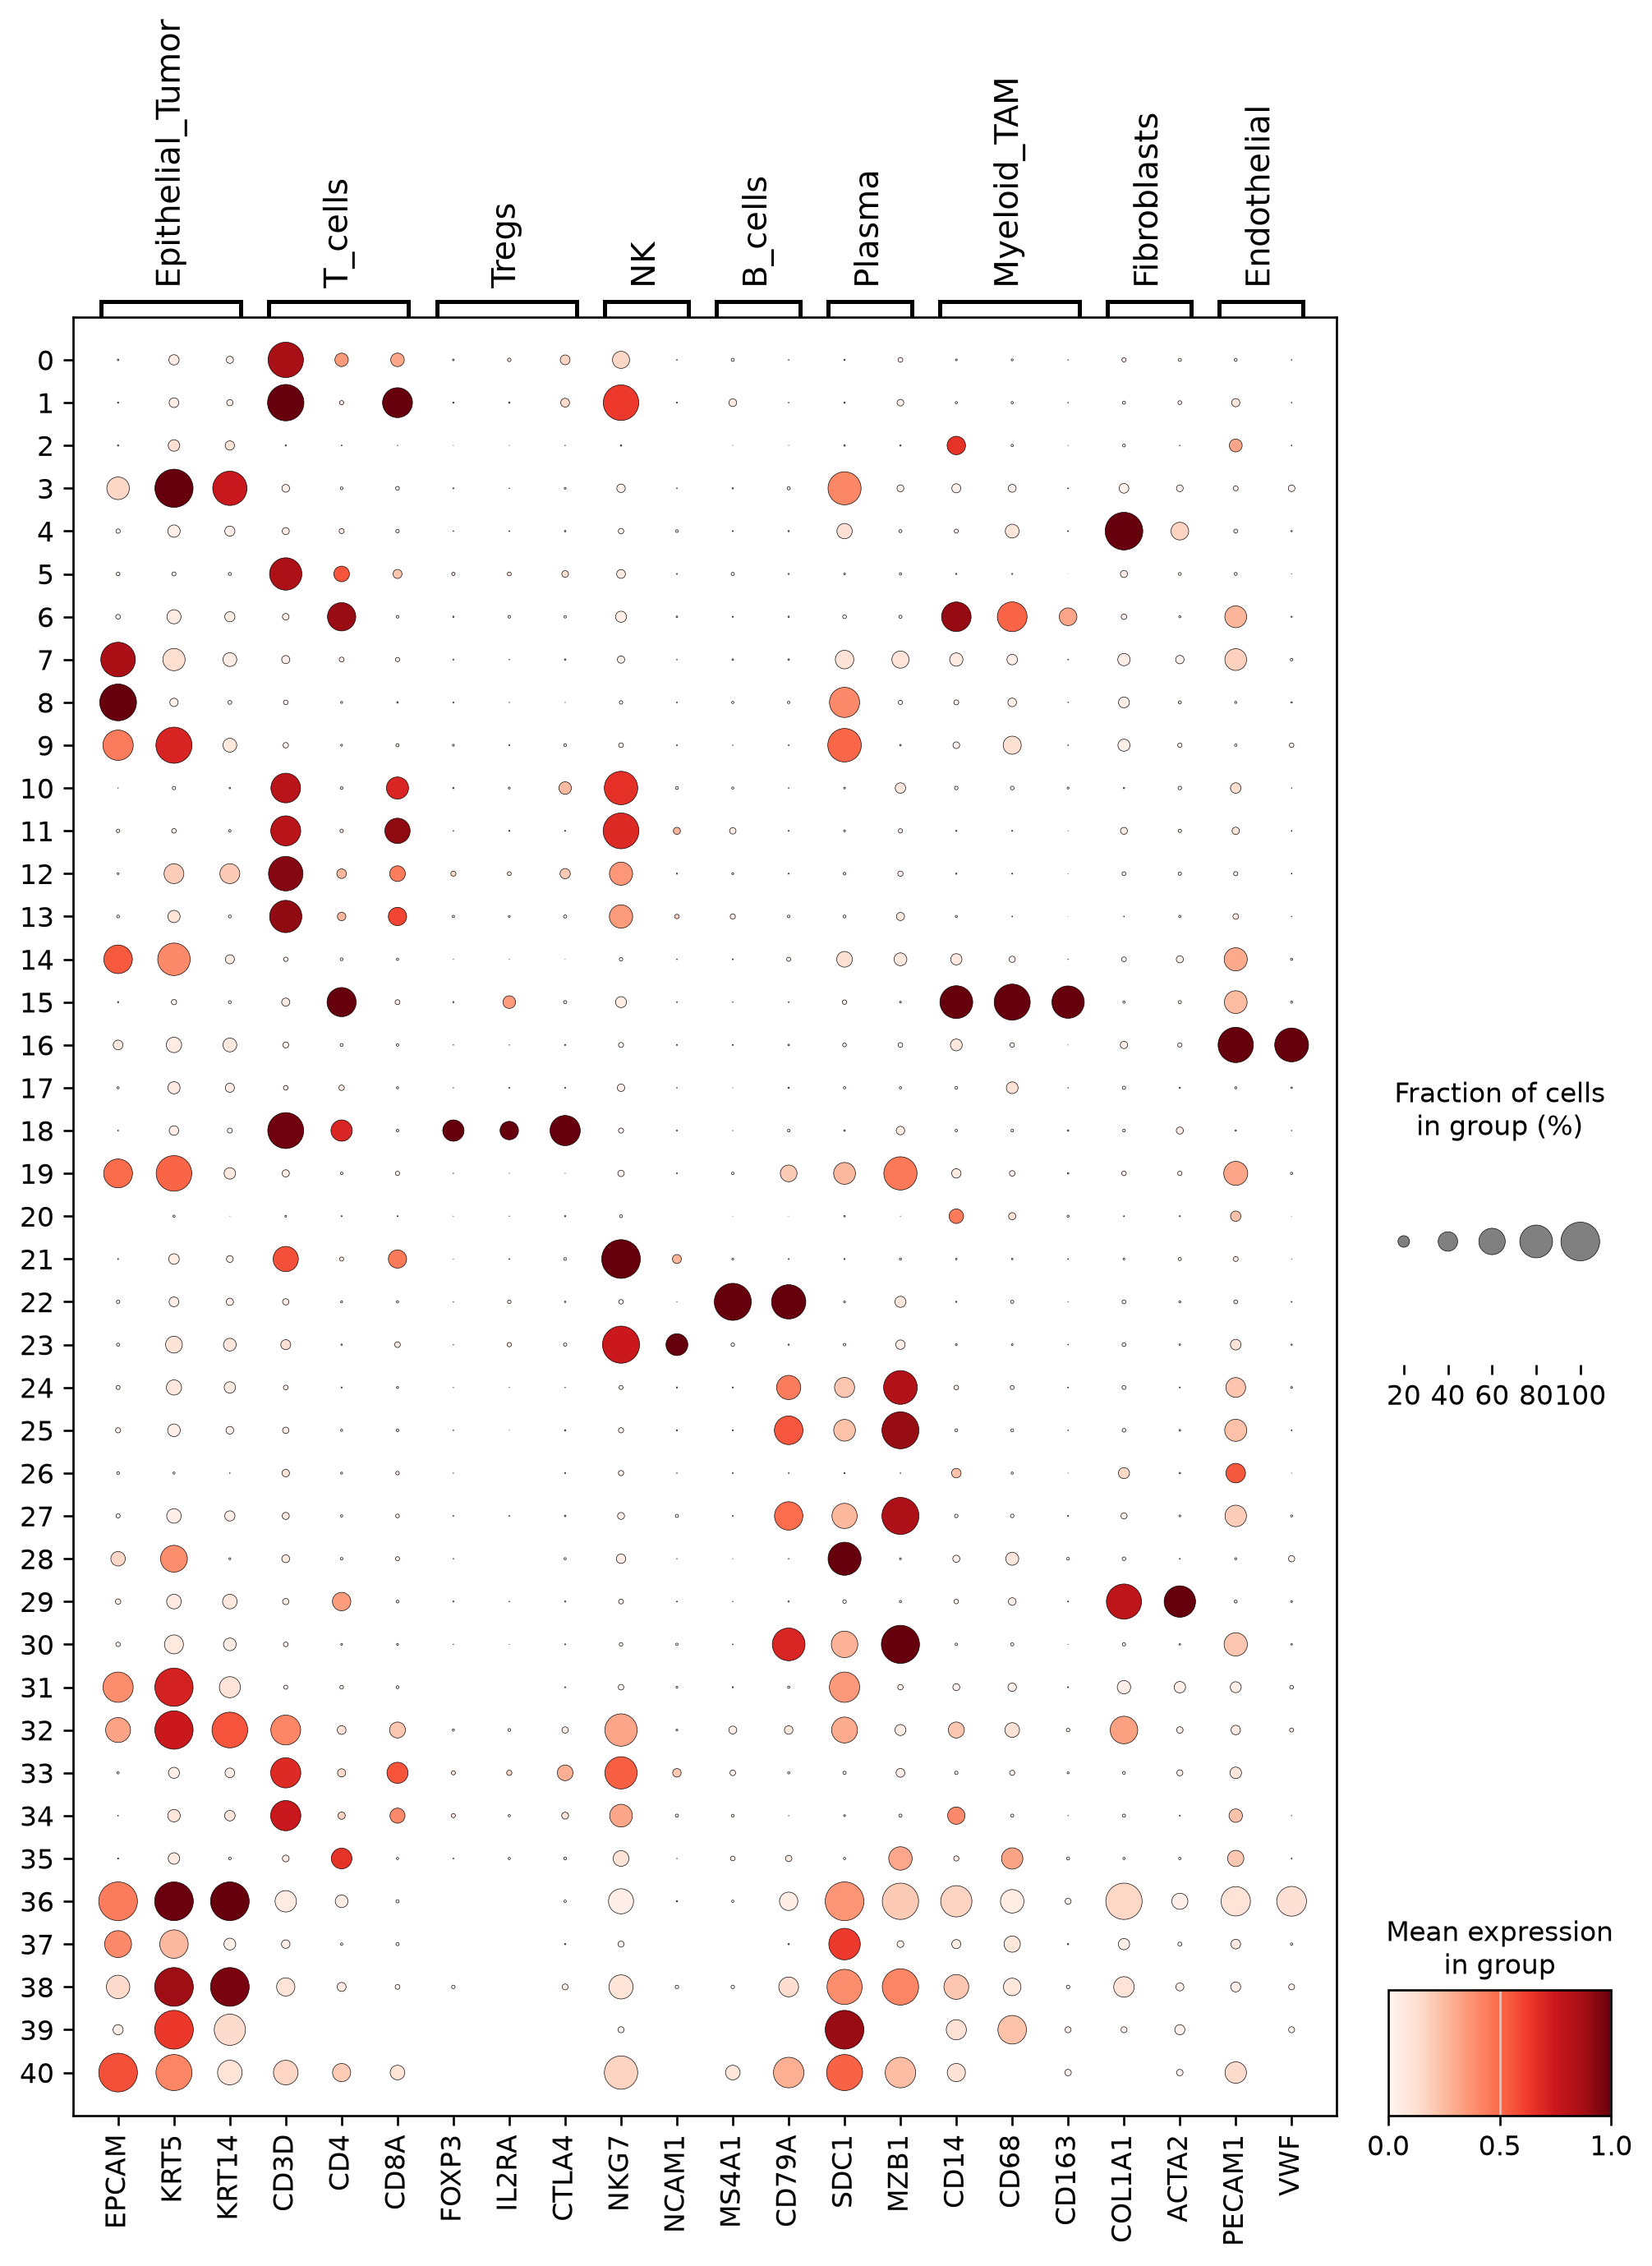

In [35]:
# DotPlot (cluster-wise marker expression)
sc.pl.dotplot(
    adata,
    var_names=lineage_dict,
    groupby="leiden_res_0.8",
    standard_scale="var",
    figsize=(10,12)
)

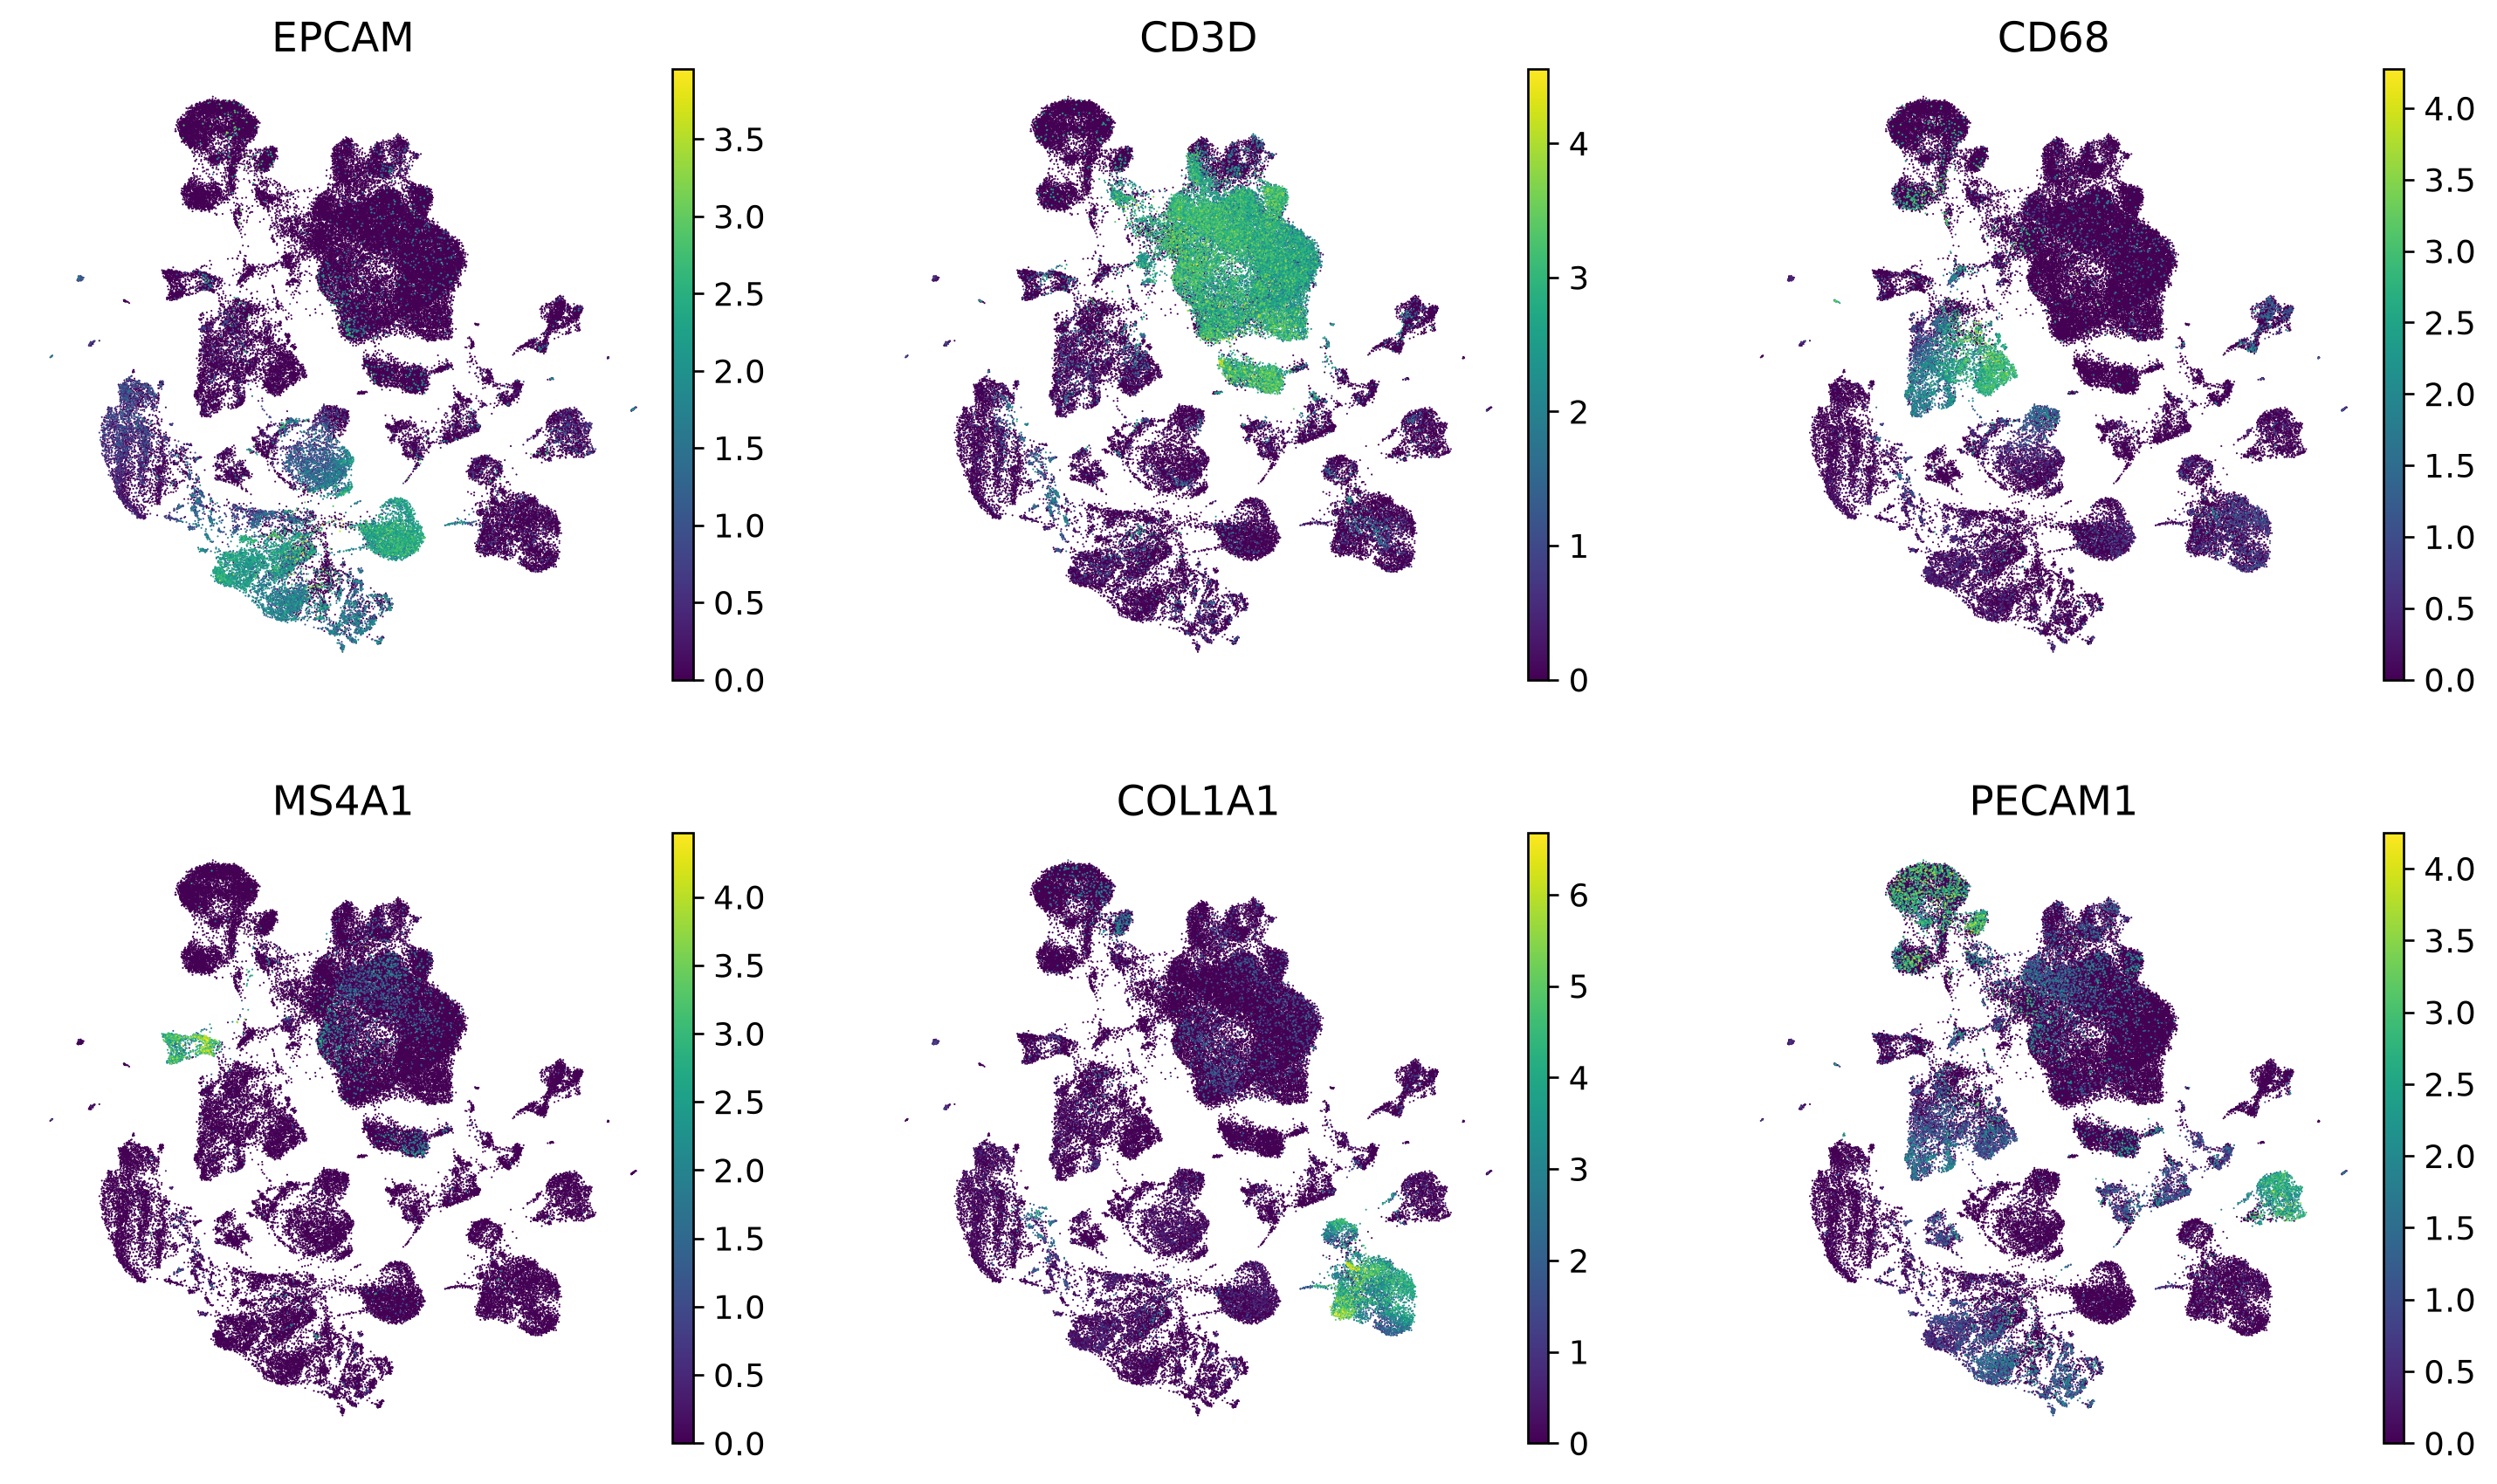

In [36]:
#UMAP marker visualization
sc.pl.umap(
    adata,
    color=[
        "EPCAM",
        "CD3D",
        "CD68",
        "MS4A1",
        "COL1A1",
        "PECAM1"
    ],
    ncols=3
)

In [37]:
import matplotlib.pyplot as plt

sc.pl.dotplot(
    adata,
    var_names=lineage_dict,
    groupby="leiden_res_0.8",
    show=False
)

plt.savefig(
    "../results/TME_lineage_dotplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.close()

In [38]:
sc.pl.umap(
    adata,
    color=[
        "EPCAM",
        "CD3D",
        "CD68",
        "MS4A1",
        "COL1A1",
        "PECAM1"
    ],
    ncols=3,
    show=False
)

plt.savefig(
    "../results/TME_marker_UMAP.png",
    dpi=600,
    bbox_inches="tight"
)

plt.close()

# Step 8.6: Evaluating T-Cell Exhaustion & Immune Checkpoint Expression

In [39]:
# T-cell exhaustion and immune checkpoint genes

exhaustion_genes = [
    "PDCD1",
    "CTLA4",
    "HAVCR2",
    "LAG3",
    "TIGIT",
    "FOXP3"
]


# Keep only genes available in your dataset

available_exhaustion = [
    g for g in exhaustion_genes
    if g in adata.var_names
]


print("Available exhaustion genes:")
print(available_exhaustion)

Available exhaustion genes:
['PDCD1', 'CTLA4', 'HAVCR2', 'LAG3', 'TIGIT', 'FOXP3']


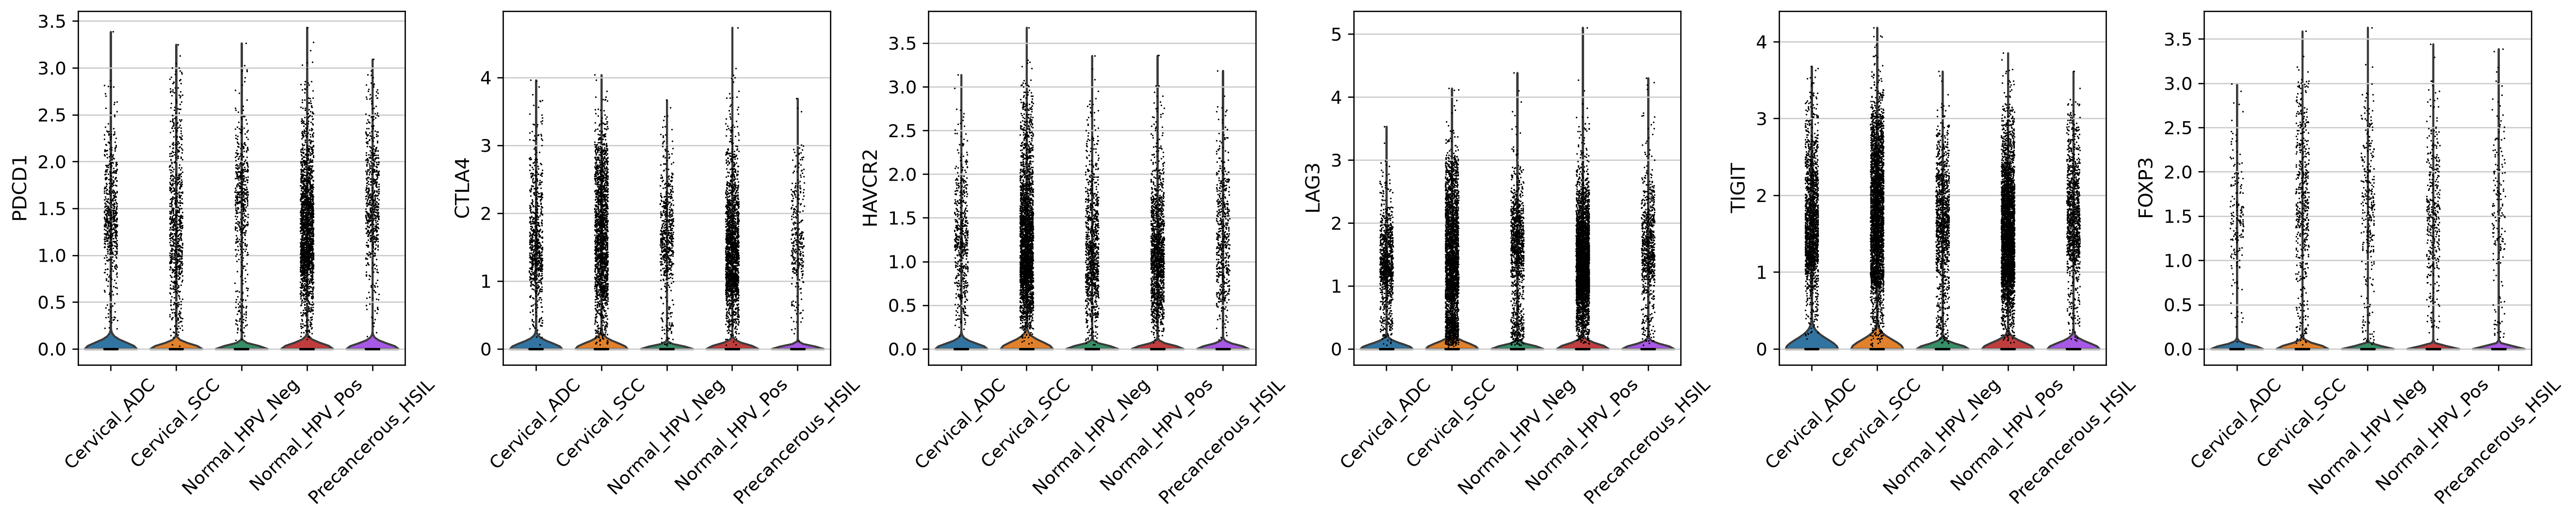

In [40]:
# Violin plot of exhaustion genes
sc.pl.violin(
    adata,
    keys=available_exhaustion,
    groupby="group",
    rotation=45,
    multi_panel=True
)

In [41]:

# Differential expression between Tumor and Normal tissue

sc.tl.rank_genes_groups(
    adata,
    groupby="tissue_type",
    method="wilcoxon"
)

print("Differential expression completed")

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:04)
Differential expression completed


In [42]:
# Extract Tumor upregulated genes
tumor_de_df = sc.get.rank_genes_groups_df(
    adata,
    group="Tumor"
)


print("Top upregulated genes in Cervical Tumor tissue:")

print(
    tumor_de_df.head(15)
)

Top upregulated genes in Cervical Tumor tissue:
    names      scores  logfoldchanges  pvals  pvals_adj
0   HLA-A  112.276810        1.361596    0.0        0.0
1     B2M  107.455757        1.027198    0.0        0.0
2   HLA-B   88.459709        0.945890    0.0        0.0
3   HLA-C   86.145836        0.906289    0.0        0.0
4   HLA-E   73.305794        1.015074    0.0        0.0
5   STAT1   68.267715        2.109646    0.0        0.0
6   PSMB9   67.695587        1.361745    0.0        0.0
7   ISG15   64.865250        1.838968    0.0        0.0
8    GBP1   59.805096        2.557301    0.0        0.0
9    IFI6   59.434105        2.141032    0.0        0.0
10   IRF1   59.203022        1.272352    0.0        0.0
11    UBC   58.201138        0.590761    0.0        0.0
12    FOS   58.006664        1.316216    0.0        0.0
13  DUSP1   57.218307        1.194334    0.0        0.0
14   JUNB   56.850540        1.141967    0.0        0.0


In [43]:
import matplotlib.pyplot as plt

sc.pl.violin(
    adata,
    keys=available_exhaustion,
    groupby="group",
    rotation=45,
    multi_panel=True,
    show=False
)

plt.savefig(
    "../results/Tcell_exhaustion_violin.png",
    dpi=600,
    bbox_inches="tight"
)

plt.close()

print("Violin plot saved")

Violin plot saved


In [44]:
tumor_de_df.to_csv(
    "../results/Tumor_vs_Normal_DE_genes.csv",
    index=False
)

print("DE table saved")

DE table saved


# Step 8.7: Pathway Enrichment Analysis with GSEApy

In [45]:
tumor_de_df

,names,scores,logfoldchanges,pvals,pvals_adj
0,HLA-A,112.276810,1.361596,0.0,0.0
1,B2M,107.455757,1.027198,0.0,0.0
2,HLA-B,88.459709,0.945890,0.0,0.0
3,HLA-C,86.145836,0.906289,0.0,0.0
4,HLA-E,73.305794,1.015074,0.0,0.0
...,...,...,...,...,...
18356,WFDC2,-82.766190,-2.639659,0.0,0.0
18357,SLPI,-92.272957,-2.670341,0.0,0.0
18358,IGLC2,-92.588097,-3.562206,0.0,0.0
18359,IGHA1,-108.808395,-4.130073,0.0,0.0


In [46]:
# Import GSEApy
import gseapy as gp

print("GSEApy loaded")

GSEApy loaded


In [47]:
# Select significant tumor genes
sig_tumor_genes = tumor_de_df[
    (tumor_de_df["logfoldchanges"] > 1.0) &
    (tumor_de_df["pvals_adj"] < 0.01)
]["names"].tolist()[:100]


print(
    "Number of significant tumor genes:",
    len(sig_tumor_genes)
)

Number of significant tumor genes: 100


In [48]:
# Run Enrichr pathway analysis
if len(sig_tumor_genes) > 0:

    enr = gp.enrichr(
        gene_list=sig_tumor_genes,
        gene_sets=[
            "KEGG_2021_Human",
            "GO_Biological_Process_2023",
            "Reactome_2022"
        ],
        organism="human",
        outdir=None
    )

    print("Top enriched pathways in Cervical Carcinoma:")
    
    print(
        enr.results.head(10)[
            [
                "Gene_set",
                "Term",
                "Adjusted P-value"
            ]
        ]
    )

else:
    print("No significant tumor genes found")

Top enriched pathways in Cervical Carcinoma:
          Gene_set                                 Term  Adjusted P-value
0  KEGG_2021_Human         Epstein-Barr virus infection      2.695762e-14
1  KEGG_2021_Human                          Influenza A      5.314274e-13
2  KEGG_2021_Human  NOD-like receptor signaling pathway      2.980180e-10
3  KEGG_2021_Human                            Phagosome      4.989993e-10
4  KEGG_2021_Human                              Measles      2.886610e-09
5  KEGG_2021_Human                  Coronavirus disease      3.369307e-09
6  KEGG_2021_Human  Antigen processing and presentation      3.736472e-09
7  KEGG_2021_Human      Human cytomegalovirus infection      2.374101e-08
8  KEGG_2021_Human                          Hepatitis C      9.857710e-08
9  KEGG_2021_Human     Herpes simplex virus 1 infection      3.642995e-07


In [49]:
enr.results.to_csv(
    "../results/Cervical_Carcinoma_Pathway_Enrichment.csv",
    index=False
)

print("Pathway enrichment saved")

Pathway enrichment saved
